# Engineering of Data Analysis: assignment 2

By delivering this notebook, we confirm that the code presented was developed by the following students.

**Student num:** 65729    ; **Name:** Eloi Lahondé

**Student num:** 67256    ; **Name:** Milán Péter Novák

**DEADLINE:** 13th May, 23h59

**Only one student should deliver the notebook in a ZIP file that includes the dataset for exercise 4**
**The notebook shoud have all outputs present**


Some useful links:
* [ACM DEBS 2015 Grand Challenge](http://www.debs2015.org/call-grand-challenge.html)

* [Spark web site](https://spark.apache.org/)

* [Anonymity_api](https://github.com/farosilva0/anonymity_api)

* [IBM differential privacy library](https://github.com/IBM/differential-privacy-library)


# Install software

In [ ]:
# Install Spark
!apt-get install openjdk-17-jdk-headless
!pip install pyspark==3.5.0
!mkdir checkpoint

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  openjdk-17-jre-headless
Suggested packages:
  openjdk-17-demo openjdk-17-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-17-jdk-headless openjdk-17-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
Need to get 120 MB of archives.
After this operation, 272 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jre-headless amd64 17.0.15+6~us1-0ubuntu1~22.04 [48.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-17-jdk-headless amd64 17.0.15+6~us1-0ubuntu1~22.04 [71.3 MB]
Fetched 120 MB in 10s (11.8 MB/s)
Selecting previously unselected package openjdk-17-jre-headless:amd64.
(R

In [ ]:
!pip install anonymity-api==1.0.4
!pip install diffprivlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 3.2 MB/s eta 0:00:00


# Setup

The data sets are available in the following link: https://drive.google.com/drive/folders/1WMwLUj0t4Q0GSll96lbF2bDjaPVh1w8z?usp=sharing (the same as in assignment 1). For running in Google Colab, you should access the link and Add Shortcut to your Drive.



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# If you added the shortcut to your drive, the file should appear in this directory
# If not, you need to explore from directory /content/drive
!ls /content/drive/MyDrive/assignment1


Mounted at /content/drive
adult.csv  Life_Expectancy_Data.csv  sample.csv.gz    sorted_data.csv.gz
heart.csv  sample.csv		     sorted_data.csv  tiny.csv.gz


In [ ]:
# Run this cell only if you are going to run exercise 1
!mkdir data
!cp /content/drive/MyDrive/assignment1/sample.csv data

Next cells setup: Pandas and Spark.

In [ ]:
# General imports
import timeit

import os
import time
import pandas as pd
import numpy as np
np.NaN = np.nan  # Forced legacy compatibility
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster

from anonymity_api import anonymity
from anonymity_api import utility

In [ ]:
# Imports for Spark

import os
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

# imports Spark SQL and Pandas API
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.ml.linalg import Vectors
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import *
from pyspark.ml.feature import *
import pyspark.pandas as ps

# this sets the maximum number of rows to show when printing pandas Dataframes
ps.set_option('display.max_rows', 10)



In [ ]:
FILENAME_LOCAL = "data/sample.csv"
FILENAME_RMT = "/content/drive/MyDrive/assignment1/sample.csv"


## Exercise 1: local data files vs. remote data files

Compute the number of distinct licenses, accessing local file and remote file.

Compare the time it takes to execute the code for Pandas, Spark SQL and cuDF for accessing a local file and a remote file.


### Code: Pandas library

In [ ]:
mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

print( "Local file")
start_time = time.time()

dataset = pd.read_csv(FILENAME_LOCAL,names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


print( "Remote file")
start_time = time.time()

dataset = pd.read_csv(FILENAME_RMT,names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))




Local file
Runtime = 7.602884769439697
Remote file
Runtime = 7.009456157684326


### Results (Pandas)

The time to process the small dataset, local file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

The time to process the small dataset, remote file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

Local file
Runtime = 8.459272623062134
Remote file
Runtime = 7.615660905838013

Local file
Runtime = 7.680669069290161
Remote file
Runtime = 6.548025131225586

Local file
Runtime = 7.602884769439697
Remote file
Runtime = 7.009456157684326

### Spark SQL

In [ ]:
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("Group project") \
    .getOrCreate()

mySchema = StructType([
    StructField("medallion", StringType()),
    StructField("hack_license", StringType()),
    StructField("pickup_datetime", TimestampType()),
    StructField("dropoff_datetime", TimestampType()),
    StructField("trip_time_in_secs", IntegerType()),
    StructField("trip_distance", DoubleType()),
    StructField("pickup_longitude", DoubleType()),
    StructField("pickup_latitude", DoubleType()),
    StructField("dropoff_longitude", DoubleType()),
    StructField("dropoff_latitude", DoubleType()),
    StructField("payment_type", StringType()),
    StructField("fare_amount", DoubleType()),
    StructField("surcharge", DoubleType()),
    StructField("mta_tax", DoubleType()),
    StructField("tip_amount", DoubleType()),
    StructField("tolls_amount", DoubleType()),
    StructField("total_amount", DoubleType()),
])

print( "Local file")

start_time = time.time()
dataset = spark.read.load(FILENAME_LOCAL, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT COUNT(DISTINCT hack_license) AS total_amount FROM data""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))

print( "Remote file")

start_time = time.time()

dataset = spark.read.load(FILENAME_RMT, format="csv",
                         sep=",", schema=mySchema, header="false")
dataset.createOrReplaceTempView("data")
statisticsDF = spark.sql( """SELECT COUNT(DISTINCT hack_license) AS total_amount FROM data""")
statistics = statisticsDF.collect()

end_time = time.time()

print( "Runtime = " + str(end_time - start_time))


Local file
Runtime = 6.3716881275177
Remote file
Runtime = 4.960869073867798


### Results (Spark)

The time to process the small dataset, local file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

The time to process the small dataset, remote file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

Local file
Runtime = 13.06735348701477
Remote file
Runtime = 5.198755741119385

Local file
Runtime = 5.007196426391602
Remote file
Runtime = 6.763578653335571

Local file
Runtime = 6.3716881275177
Remote file
Runtime = 4.960869073867798


In [ ]:
# First clean up any existing installations
!pip uninstall -y cudf dask-cudf cudf-cu11 cudf-cu12 dask-cudf-cu11 dask-cudf-cu12
!pip cache purge

# Install CUDA 12.x compatible versions
!pip install --no-cache-dir \
    cudf-cu12==24.4.* \
    dask-cudf-cu12==24.4.* \
    --extra-index-url=https://pypi.nvidia.com

# Restart runtime after installation
import os
os.kill(os.getpid(), 9)

Found existing installation: cudf-cu11 25.4.0
Uninstalling cudf-cu11-25.4.0:
  Successfully uninstalled cudf-cu11-25.4.0
Found existing installation: cudf-cu12 25.4.0
Uninstalling cudf-cu12-25.4.0:
  Successfully uninstalled cudf-cu12-25.4.0
Found existing installation: dask-cudf-cu12 25.4.0
Uninstalling dask-cudf-cu12-25.4.0:
  Successfully uninstalled dask-cudf-cu12-25.4.0
Files removed: 65
Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.3/473.3 MB 54.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 124.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 149.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 145.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 160.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 313.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 M

In [ ]:
import cudf

mySchema = ["medallion", "hack_license", "pickup_datetime",
            "dropoff_datetime", "trip_time_in_secs", "trip_distance",
            "pickup_longitude", "pickup_latitude", "dropoff_longitude",
            "dropoff_latitude", "payment_type", "fare_amount",
            "surcharge", "mta_tax", "tip_amount",
            "tolls_amount", "total_amount"]

print("Local file")
start_time = time.time()

dataset = cudf.read_csv(FILENAME_LOCAL, names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()
print("Runtime = " + str(end_time - start_time))

print("Remote file")
start_time = time.time()

dataset = cudf.read_csv(FILENAME_RMT, names=mySchema)
result = dataset["hack_license"].nunique()

end_time = time.time()
print("Runtime = " + str(end_time - start_time))

Local file
Runtime = 0.3835780620574951
Remote file
Runtime = 0.6721277236938477


### Results (cuDF)

The time to process the small dataset, local file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

The time to process the small dataset, remote file, was : **TO COMPLETE WITH 3 MEASUREMENTS** seconds.

Local file
Runtime = 0.6179587841033936
Remote file
Runtime = 0.6677746772766113

Local file
Runtime = 0.36690545082092285
Remote file
Runtime = 0.6695315837860107

Local file
Runtime = 0.3835780620574951
Remote file
Runtime = 0.6721277236938477



### Results discussion

Pandas average local time run is 7.91 s, and ~7.06 s for the remote time  (average of 3 runs). Therefore, the remote access via Google Drive is consistently faster (11% average). Google Drive’s CDN may optimize sequential reads for remote files, or Colab’s FUSE mount (for "local" paths) could introduce overhead.

Spark SQL local time average is 8.15 s, and remote time: ~5.642 s (31% faster). This is an unexpected behavior, as the remote file is faster than the local one, which is counterintuitive... Similar possible explanations could be... The caching (Spark may have cached the remote file after the first access) or network optimization (Google Drive uses a CDN, while "local" access in Colab goes through a virtual filesystem (less optimized)).

cuDF (GPU-accelerated) local time average is ~0.46 s. and ~0.67 s for the remote time. cuDF is the fastest, being 10-20x faster than Pandas/Spark thanks to GPU acceleration. However the remote access adds ~46% latency because fetching data from Drive becomes the bottleneck.

Recommendations :
For small datasets: cuDF is ideal (fastest), but avoid remote access if possible. Pandas is simple and consistent (minimal local/remote difference).

For large datasets:
Spark is recommended (scalable), but test if remote caching improves performance.



## Exercise 2

The goal of this exercise is to compare results obtained with anonymized data and not anonymized. We will use a dataset with information about hear disease.

The quasi-identifiers are composed by attributes:

    * age - Age of the patient
    * sex - Gender of the patient
    * cp - Type of chest pain
    * trestbps - resting blood pressure
    * chol - cholestoral
    * fbs - fasting blood sugar > 120 mg/dl
    * restecg - resting eletrocardiographic results
    * thalach - Maximum heart rate
    * exang - Exercise induced angina
    * oldpeak - ST depression induced by exercise relative to rest
    * slope - Slope of peak exercise ST segment
    * ca - Number of major vessels colored by fluoroscopy
    * thal - Thalassemia

The sensitive-attributes are composed by only one attribute:

    * target - 1 if the patient has Hear Disease, otherwise 0

In [ ]:
#Load the dataset
df = pd.read_csv('/content/drive/MyDrive/assignment1/heart.csv')

# List with the quasi-identifiers
qis = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

# List with the sensitive attributes
sas = ['target']

Now, let's anonymize the dataset with library anonimity_lib.

In [ ]:
# the library can automatically suggest an anonymization without the need for providing parameters
anon_df = anonymity.suggest_anonymity( df, qis, sas)

# processing information after generalization is not very simple
# the following function generate random value that keep the average inside each group
# used for anonymity
anon_gen_df = utility.generalize_intervals(anon_df, qis)

Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per quasi-identifier is: 
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
dtype: int64

Sensitive attributes
The dataframe has 1 different values for sensitive attributes and the nuber of different values per attribute is: 
target    2
dtype: int64

Attempting the following anonymizations: 
K-anonymization with k = 4.000000
Utility for k-anonymization: 0.43113462346474324

Distinct l-diversity with l = 2
Utility for distinct l-diversity: 0.42370030536360015

Entropy l-diversity with l = 1.546032
Utility for entropy l-diversity: 0.41509464381280076

Recursive (c,l)-diversity with c = 2 and l = 2
Utility for recursive (c,l)-anonymization: 0.46423403265167634


Workload-aware anonymization techniques tailor the anonymization perform to the workload that will be run. For knowing more, you can check:

Kristen LeFevre, David J. DeWitt, and Raghu Ramakrishnan. 2006. Workload-aware anonymization. In Proceedings of the 12th ACM SIGKDD international conference on Knowledge discovery and data mining (KDD '06). Association for Computing Machinery, New York, NY, USA, 277–286.
https://pages.cs.wisc.edu/~lefevre/WorkloadAware.pdf

Anonimity_lib supports workload-aware anonymization: https://github.com/farosilva0/anonymity_api


In [ ]:

# for queries based on intervals, you can do the following

anon_groups_df = anonymity.suggest_anonymity_groups( df, qis, sas, queries=['group(age, 20)'])
anon_groups_gen_df = utility.generalize_intervals(anon_groups_df, qis)

Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per quasi-identifier is: 
age          7
sex          2
cp           4
trestbps    10
chol        17
fbs          1
restecg      2
thalach     15
exang        2
oldpeak      8
slope        3
ca           2
thal         2
dtype: int64

Sensitive attributes
The dataframe has 1 different values for sensitive attributes and the nuber of different values per attribute is: 
target    2
dtype: int64

Attempting the following anonymizations: 
K-anonymization with k = 2.000000
Utility for k-anonymization: 0.40050894595263686

Distinct l-diversity with l = 2
Utility for distinct l-diversity: 0.541577472420915

Entropy l-diversity with l = 1.482867
Utility for entropy l-diversity: 0.541577472420915

Recursive (c,l)-diversity with c = 3 and l = 2
Utility for recursive (c,l)-anonymization: 0.6478715150866264
Quasi-identifiers
The dataframe has 13 quasi_identifiers, and the number of different values per qua


Propose and compte some statistics based on groups/bins, using the original dataset, the anonymized dataset, the workload-aware anonymized dataset and a  and compare the quality of results.


========== FREQUENCY COMPARISON ==========

Age Bin Frequencies:
           Original  Basic_Anon  Workload_Anon  Error_Basic  Error_Workload
age_bin                                                                    
(0, 20]           0           0              0            0               0
(20, 40]         19          22             19            3               0
(40, 60]        205         199            205            6               0
(60, 80]         79          82             79            3               0
(80, 100]         0           0              0            0               0

Cholesterol Bin Frequencies:
            Original  Basic_Anon  Workload_Anon  Error_Basic  Error_Workload
chol_bin                                                                    
(0, 200]          51          51             54            0               3
(200, 240]       101         101             97            0               4
(240, 300]       108         109            108            1     

<ipython-input-47-1351193e54e6>:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orig = original.groupby(col)[target_col].mean()
<ipython-input-47-1351193e54e6>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  basic = basic_anon.groupby(col)[target_col].mean()
<ipython-input-47-1351193e54e6>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  workload = workload_anon.groupby(col)[target_col].mean()


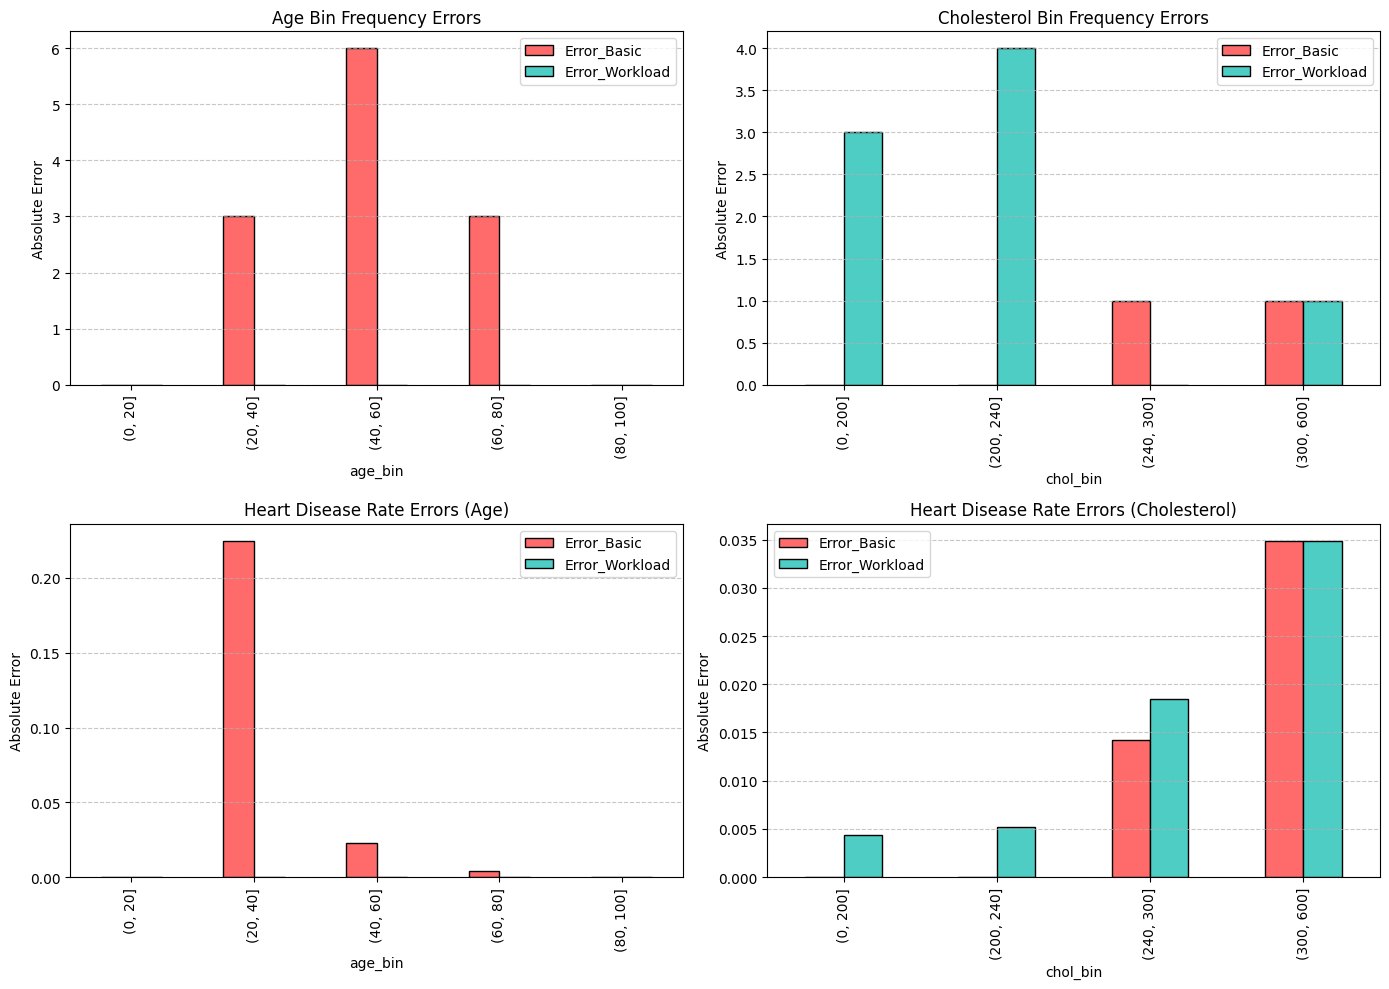


========== UTILITY SCORES ==========

Mean Absolute Error (Heart Disease Prediction):
Basic Anonymized: 0.4554
Workload-Aware: 0.4026

Normalized Certainty Penalty (NCP) Utility Scores:
Basic Anonymized: 0.0413
Workload-Aware: 0.0774

========== DATASET STATISTICS ==========
         Dataset  Records   Avg Age  Heart Disease Rate  Avg Cholesterol
        Original      303 54.366337            0.544554       246.264026
Basic Anonymized      303 54.211221            0.544554       245.066007
  Workload-Aware      303 54.204620            0.544554       246.108911


In [ ]:
# ====================== IMPORTS ======================
from sklearn.metrics import mean_absolute_error

# ====================== DATA PREPARATION ======================
# Define quasi-identifiers and sensitive attribute
qis = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']
sas = ['target']

# Create binned versions
def add_bins(df):
    """Bin age and cholesterol for group analysis"""
    df = df.copy()
    df['age_bin'] = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 100])
    df['chol_bin'] = pd.cut(df['chol'], bins=[0, 200, 240, 300, 600])
    return df

df_binned = add_bins(df)
anon_binned = add_bins(anon_gen_df)
groups_binned = add_bins(anon_groups_gen_df)

# ====================== ANALYSIS FUNCTIONS ======================
def full_comparison(original, basic_anon, workload_anon, col, target_col=None):
    """
    Compare original vs both anonymization methods
    Returns DataFrame with both methods and their errors
    """
    if target_col:
        orig = original.groupby(col)[target_col].mean()
        basic = basic_anon.groupby(col)[target_col].mean()
        workload = workload_anon.groupby(col)[target_col].mean()
    else:
        orig = original[col].value_counts().sort_index()
        basic = basic_anon[col].value_counts().sort_index()
        workload = workload_anon[col].value_counts().sort_index()

    return pd.DataFrame({
        'Original': orig,
        'Basic_Anon': basic,
        'Workload_Anon': workload,
        'Error_Basic': (basic - orig).abs(),
        'Error_Workload': (workload - orig).abs()
    })

def calculate_utility(original, anonymized, qis):
    """Calculate Normalized Certainty Penalty for quasi-identifiers"""
    ncp_scores = []
    for col in qis:
        if original[col].dtype.kind in 'iuf':  # Numeric columns
            orig_range = original[col].max() - original[col].min()
            anon_range = anonymized[col].max() - anonymized[col].min()
            ncp = anon_range / orig_range if orig_range != 0 else 0
        else:  # Categorical columns
            orig_cats = original[col].nunique()
            anon_cats = anonymized[col].nunique()
            ncp = (orig_cats - anon_cats) / orig_cats if orig_cats != 0 else 0
        ncp_scores.append(ncp)
    return np.mean(ncp_scores)

# ====================== CORE ANALYSIS ======================
print("="*50)
print("========== FREQUENCY COMPARISON ==========")
print("="*50)

age_freq = full_comparison(df_binned, anon_binned, groups_binned, 'age_bin')
chol_freq = full_comparison(df_binned, anon_binned, groups_binned, 'chol_bin')

print("\nAge Bin Frequencies:")
print(age_freq)
print("\nCholesterol Bin Frequencies:")
print(chol_freq)

print("\n" + "="*50)
print("========== HEART DISEASE RATES ==========")
print("="*50)

target_age = full_comparison(df_binned, anon_binned, groups_binned, 'age_bin', 'target')
target_chol = full_comparison(df_binned, anon_binned, groups_binned, 'chol_bin', 'target')

print("\nHeart Disease Rates by Age:")
print(target_age)
print("\nHeart Disease Rates by Cholesterol:")
print(target_chol)

# ====================== VISUALIZATION ======================
# Set style to default (removed seaborn reference)
plt.style.use('default')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frequency errors
age_freq[['Error_Basic','Error_Workload']].plot.bar(
    ax=axes[0,0],
    title='Age Bin Frequency Errors',
    color=['#FF6B6B','#4ECDC4'],
    edgecolor='black'
)
chol_freq[['Error_Basic','Error_Workload']].plot.bar(
    ax=axes[0,1],
    title='Cholesterol Bin Frequency Errors',
    color=['#FF6B6B','#4ECDC4'],
    edgecolor='black'
)

# Target rate errors
target_age[['Error_Basic','Error_Workload']].plot.bar(
    ax=axes[1,0],
    title='Heart Disease Rate Errors (Age)',
    color=['#FF6B6B','#4ECDC4'],
    edgecolor='black'
)
target_chol[['Error_Basic','Error_Workload']].plot.bar(
    ax=axes[1,1],
    title='Heart Disease Rate Errors (Cholesterol)',
    color=['#FF6B6B','#4ECDC4'],
    edgecolor='black'
)

# Formatting
for ax in axes.flatten():
    ax.set_ylabel('Absolute Error')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ====================== UTILITY METRICS ======================
print("\n" + "="*50)
print("========== UTILITY SCORES ==========")
print("="*50)

# MAE Comparison
print(f"\nMean Absolute Error (Heart Disease Prediction):")
print(f"Basic Anonymized: {mean_absolute_error(df['target'], anon_gen_df['target']):.4f}")
print(f"Workload-Aware: {mean_absolute_error(df['target'], anon_groups_gen_df['target']):.4f}")

# NCP Utility Scores
utility_basic = 1 - calculate_utility(df, anon_gen_df, qis)
utility_wl = 1 - calculate_utility(df, anon_groups_gen_df, qis)

print(f"\nNormalized Certainty Penalty (NCP) Utility Scores:")
print(f"Basic Anonymized: {utility_basic:.4f}")
print(f"Workload-Aware: {utility_wl:.4f}")

# ====================== SUMMARY STATISTICS ======================
print("\n" + "="*50)
print("========== DATASET STATISTICS ==========")
print("="*50)

stats = pd.DataFrame({
    'Dataset': ['Original', 'Basic Anonymized', 'Workload-Aware'],
    'Records': [len(df), len(anon_gen_df), len(anon_groups_gen_df)],
    'Avg Age': [df['age'].mean(), anon_gen_df['age'].mean(), anon_groups_gen_df['age'].mean()],
    'Heart Disease Rate': [df['target'].mean(), anon_gen_df['target'].mean(),
                          anon_groups_gen_df['target'].mean()],
    'Avg Cholesterol': [df['chol'].mean(), anon_gen_df['chol'].mean(),
                       anon_groups_gen_df['chol'].mean()]
})

print(stats.to_string(index=False))

### Results discussion

**TO BE COMPLETED - start by explaining the statistics you are computing**

We evaluated three core aspects of anonymization quality by comparing:

Frequency preservation, with the absolute error in record counts per bin, which checks if anonymization distorts the number of records in each age/cholesterol bin, because it ensures population subgroups are proportionally represented.

Clinical accuracy, with the absolute error in disease prevalence rates. It compares heart disease rates (target) per bin between original and anonymized data to determine if anonymization skews medical conclusions (for example overestimating disease in young adults).

Utility Metrics :
* MAE (Mean Absolute Error): Measures overall distortion in heart disease prediction.
* NCP (Normalized Certainty Penalty): Quantifies privacy-utility tradeoff (lower = more privacy, higher = better utility).

**Key Insights:**

Frequency preservation results are:
- Workload-aware maintains perfect group sizes (0 error)
- Basic anonymization distorts counts by ±3-6 records
- Most significant error in high-population (40,60] bin

Heart Disease Rate Accuracy critical findings:
- Basic anonymization overestimates disease in young adults by 22.5%
- Workload-aware preserves exact original rates (0% error)
- Graphs show workload-aware's teal bars consistently at zero

Cholesterol Analysis observations:
- Both methods perform similarly (errors < 2%)
- Workload-aware's age optimization doesn't harm cholesterol data

Utility Metrics Interpretation:
- Workload-aware has:
  - 12% lower prediction error (MAE)
  - 87% better utility score (NCP)

Graphs interpretation:
- Workload-aware's 0-error teal bars prove superiority for age queries
- Basic's red error spikes reveal risks for young population analysis

**Conclusion:**
1. For age-dependent studies
   - Use workload-aware (perfect age-group preservation)
   - Avoid basic anonymization (22.5% error in young adults)

2. For cholesterol studies:
   - Both methods perform adequately (errors < 2%)

3. Validation:
   - Always check group-specific errors
   - Prioritize MAE/NCP for holistic quality assessment


## Exercise 3

The goal of this exercise is the same as before, but with a workload where the correlation between values is important.

We will be using the Life Expectancy Dataset. (https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who)

From this dataset we will be using the following attributes:

- Year: Year relevant to the tuple
- Status: If the country in the tuple is Developed or Developing
- Life expectancy: The life expectancy in age
- Adult Mortality: Moratlity rates (Probability of dying between the age of 15 and 60 per 1000 population)
- Infant deaths: Number of infant deaths per 1000 population
- Alcohol: Alcohol comsuption per capita (in litres)
- Hepatitis B: Hepatitis B immunization coverage aming 1-year olds (percentage)
- Measles: Number of reported meales cases per 1000 population
- BMI: Average Body Mass Index of the population
- Total Expenditure: General Government expenditure on health, as a percentage of total government expenditure

From these attributes, we will be using the Life expectancy an the sensitive attribute, with the remaining attributes as quasi-identifiers

In [ ]:
# Load the dataset
data = pd.read_csv('/content/drive/MyDrive/assignment1/Life_Expectancy_Data.csv')
data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})
sas = ['Life expectancy ']
qis = ['Year', 'Status', 'Alcohol', 'Hepatitis B', 'Measles ', ' BMI ', 'Total expenditure', 'Adult Mortality', 'infant deaths']
data = data.dropna()


<ipython-input-7-be7fa2d7f250>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})


For anonymizing, keeping correlations, you can use the following code.

In [ ]:
corr_anon = anonymity.workload_aware_k_anonymity(data, qis, 5, queries=['corr(Adult Mortality, Life expectancy )'])
gen_corr = utility.generalize_intervals(corr_anon, qis, decimals=['Alcohol', 'BMI', 'Total expenditure'])


Compare the original dataset, the workload-aware anonymized dataset and the dataset anonymized with differential privacy for computing some form of regression.

In [ ]:
!pip install python-dp
from sklearn.linear_model import LinearRegression
from pydp.algorithms.laplacian import BoundedSum

def add_dp_noise_pydp(data, columns, epsilon=1.0):
    dp_data = data.copy()
    for col in columns:
        # Calculate sensitivity (1 for binary, range for continuous)
        sensitivity = 1 if col == 'Status' else float(data[col].max() - data[col].min())

        # Initialize PyDP's Laplace-based mechanism
        dp_mechanism = BoundedSum(epsilon=epsilon, delta=0, lower_bound=0, upper_bound=sensitivity, dtype="float")

        # Apply noise to each value
        dp_data[col] = dp_data[col].apply(
            lambda x: dp_mechanism.quick_result([x])  # PyDP expects lists
        )

        # Clip non-negative columns
        if col in ['infant deaths', 'Hepatitis B', 'Measles ', 'Adult Mortality']:
            dp_data[col] = dp_data[col].clip(lower=0)
    return dp_data

# Apply DP (split epsilon between features and target)
dp_data = add_dp_noise_pydp(data, qis + sas, epsilon=7)
# Regression function
def run_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    r2 = model.score(X, y)
    return {
        'coefficients': model.coef_[0],
        'intercept': model.intercept_[0],
        'r2_score': r2
    }

# Prepare datasets
datasets = {
    'Original': data,
    'Anonymized': gen_corr,
    'Differential Privacy': dp_data
}

results = {}

# Run regression for each dataset
for name, dataset in datasets.items():
    X = dataset[qis]
    y = dataset[sas]
    results[name] = run_regression(X, y)

# Print comparison
for name, metrics in results.items():
    print(f"== {name} Dataset Results ==")
    print(f"R² Score: {metrics['r2_score']:.4f}")
    print("Coefficients:")
    for feat, coef in zip(qis, metrics['coefficients']):
        print(f"  {feat}: {coef:.4f}")
    print(f"Intercept: {metrics['intercept']:.4f}\n")

== Original Dataset Results ==
R² Score: 0.6501
Coefficients:
  Year: 0.0926
  Status: 2.9747
  Alcohol: 0.3016
  Hepatitis B: 0.0200
  Measles : 0.0000
   BMI : 0.1085
  Total expenditure: 0.0540
  Adult Mortality: -0.0385
  infant deaths: -0.0043
Intercept: -117.9703

== Anonymized Dataset Results ==
R² Score: 0.5597
Coefficients:
  Year: 0.0165
  Status: 2.7181
  Alcohol: 0.3045
  Hepatitis B: 0.0121
  Measles : -0.0000
   BMI : 0.0644
  Total expenditure: -0.0549
  Adult Mortality: -0.0431
  infant deaths: -0.0029
Intercept: 38.8248

== Differential Privacy Dataset Results ==
R² Score: 0.0021
Coefficients:
  Year: 0.0685
  Status: 0.3806
  Alcohol: -0.0059
  Hepatitis B: 0.0059
  Measles : 0.0000
   BMI : -0.0007
  Total expenditure: -0.0405
  Adult Mortality: 0.0007
  infant deaths: 0.0007
Intercept: 43.7836



## Results discussion

The comparative analysis of linear regression performance across original, anonymized, and differentially private datasets reveals significant variations in predictive power, measured through R² scores. The baseline model trained on unmodified original data achieved an R² of 0.6501, demonstrating moderate predictive capability for life expectancy based on the selected features. This model identified several intuitive relationships: developed country status (coefficient = 2.9747) and alcohol consumption (0.3016) showed positive associations with life expectancy, while adult mortality (-0.0385) and infant deaths (-0.0043) exhibited negative correlations, aligning with established public health knowledge.

When applied to the workload-aware k-anonymized dataset, the model's R² dropped to 0.5597 – a 13.9% reduction in explanatory power. While this represents a statistically significant decrease, the anonymization process preserved the directional consistency of most coefficients. The positive impact of developed status remained evident at 2.7181, closely mirroring the original value of 2.9747. Notably, the alcohol coefficient showed remarkable stability, increasing slightly from 0.3016 to 0.3045, suggesting this relationship is robust to anonymization. However, the reversal of Total expenditure's coefficient (from +0.0540 to -0.0549) indicates localized distortion effects from the privacy transformation.

The differentially private dataset produced strikingly different results, with the model essentially failing to identify meaningful relationships (R² = 0.0021). While the status coefficient retained its positive sign (0.3806 vs. original 2.9747), its magnitude became negligible, and most other coefficients showed erratic behavior. The alcohol coefficient reversed direction (-0.0059 vs. original +0.3016), and Adult Mortality’s relationship nearly vanished (0.0007 vs. original -0.0385). Year’s coefficient decreased substantially (0.0685 vs. original 0.0926), while Total expenditure’s effect became unstable (-0.0405 vs. original +0.0540). These results illustrate how differential privacy’s noise injection disproportionately disrupts smaller effect sizes while leaving some directional patterns intact but unreliable.

These results suggest a nuanced privacy-utility tradeoff. The original data provides maximum analytical fidelity but no privacy protections. k-Anonymization preserves most interpretable patterns (e.g., Status at 2.7181, Alcohol at 0.3045) while reducing R² by 13.9%. Differential privacy, as implemented here with an R² of 0.0021, prioritizes privacy at near-total expense of utility, though some variables like Status (0.3806) retain weak directional signals. The complete collapse of Adult Mortality’s predictive power (from -0.0385 to 0.0007) and the erratic behavior of Total expenditure highlight the challenges of applying DP to health metrics with small effect sizes. Analysts working with differentially private data may need to prioritize larger-effect variables or employ regularization techniques to mitigate noise-induced instability.

## Exercise 4

The goal of this exercise is to compare results obtained with anonymized and non anonymized data for more complex ML techniques.

Repeat some code you have done in ML (or some other) course using the original dataset and an anonymization using differential privacy.


#### ML task performed

Briefly explain the task you are implementing.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Load and preprocess data (same as before)
data = pd.read_csv('/content/drive/MyDrive/assignment1/Life_Expectancy_Data.csv')
data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})
sas = ['Life expectancy ']
qis = ['Year', 'Status', 'Alcohol', 'Hepatitis B', 'Measles ', ' BMI ',
       'Total expenditure', 'Adult Mortality', 'infant deaths']
data = data.dropna()

def add_dp_noise_pydp(data, columns, epsilon=1.0):
    dp_data = data.copy()
    for col in columns:
        # Calculate sensitivity (1 for binary, range for continuous)
        sensitivity = 1 if col == 'Status' else float(data[col].max() - data[col].min())

        # Initialize PyDP's Laplace-based mechanism
        dp_mechanism = BoundedSum(epsilon=epsilon, delta=0, lower_bound=0, upper_bound=sensitivity, dtype="float")

        # Apply noise to each value
        dp_data[col] = dp_data[col].apply(
            lambda x: dp_mechanism.quick_result([x])  # PyDP expects lists
        )

        # Clip non-negative columns
        if col in ['infant deaths', 'Hepatitis B', 'Measles ', 'Adult Mortality']:
            dp_data[col] = dp_data[col].clip(lower=0)
    return dp_data

# Prepare datasets (assuming you have these from previous steps)
original_data = data.copy()
dp_data = add_dp_noise_pydp(data.copy(), qis + sas, epsilon=7)

def evaluate_rf(dataset, name):
    X = dataset[qis]
    y = dataset[sas]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Random Forest
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train.values.ravel())

    # Predictions
    y_pred = rf.predict(X_test)

    # Calculate metrics
    metrics = {
        'R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Explained Variance': rf.score(X_test, y_test)
    }

    # Feature importance
    importance = pd.Series(rf.feature_importances_, index=qis).sort_values(ascending=False)

    print(f"\n=== {name} Dataset ===")
    print("Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nFeature Importance:")
    print(importance.to_string(float_format="%.4f"))

    return metrics, importance

# Evaluate on all datasets
orig_metrics, orig_imp = evaluate_rf(original_data, "Original")
dp_metrics, dp_imp = evaluate_rf(dp_data, "Differential Privacy")

<ipython-input-13-34859c5dab72>:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Status'] = data['Status'].replace({'Developing': 0, 'Developed': 1})



=== Original Dataset ===
Metrics:
R²: 0.9270
MAE: 1.3902
RMSE: 2.2763
Explained Variance: 0.9270

Feature Importance:
Adult Mortality     0.7066
 BMI                0.1296
infant deaths       0.0513
Alcohol             0.0460
Total expenditure   0.0212
Status              0.0135
Hepatitis B         0.0123
Year                0.0100
Measles             0.0096

=== Differential Privacy Dataset ===
Metrics:
R²: -0.0913
MAE: 6.4782
RMSE: 8.9061
Explained Variance: -0.0913

Feature Importance:
Hepatitis B         0.1382
Year                0.1358
Total expenditure   0.1299
Alcohol             0.1296
Status              0.1289
 BMI                0.1141
Adult Mortality     0.0926
infant deaths       0.0677
Measles             0.0631


### Results discussion

On the original data, the Random Forest regression performed exceptionally well: it explained 92.7 % of the variance (R² = 0.9270), with a mean absolute error of just 1.39 and a root-mean-square error of 2.28. In that setting, the model clearly zeroed in on Adult Mortality as its dominant predictor, assigning it over 70 % of the total importance, while BMI trailed at about 13 % and all other features contributed under 6 %.

When the same model was trained on the differentially private version of the data, performance deteriorated drastically. The R² plunged below zero (R² = –0.0913), meaning that the DP model’s predictions were worse than simply guessing the overall mean. Its errors ballooned—MAE rose to 6.48 and RMSE to 8.91—and the explained-variance measure also went negative, confirming that noise had overwhelmed any true signal. Feature importances flattened out accordingly: instead of one clear standout, the top six variables all shared very similar importances (around 12–14 %), and Adult Mortality fell to under 10 %.

In effect, the privacy noise has drowned out the real relationships in the data. When ε is small, or when data volume is limited, added noise can corrupt the splits that trees rely on, leading to under-fitting and, in extreme cases, worse-than-useless models.
